In [1]:
import os
import sys
import torch
import tqdm 
import pickle as pkl
import numpy as np

module_path = os.path.abspath('..')
if module_path not in sys.path:
    sys.path.insert(0, module_path)

from torch.utils.data import DataLoader
from datasets import TransformerConf3Dataset
from models import TransformerConf3
from utils import args_transformer, create_mask_src, create_mask_tgt

# manually specify the GPUs to use
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.multiprocessing.set_sharing_strategy('file_system')

In [2]:
parser = args_transformer()
args = parser.parse_args([
    "--metadata_path", "/mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Data/Highland_Output/NN_Data/metadata.pkl",
    "--dataset_path", "/mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Data/Highland_Output/NN_Data/{}/{}/{}.npz",
    "--checkpoint_path", "/mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Results/checkpoints",
    "--checkpoint_name", "v3",
    "--batch_size", "32",
    "--num_workers", "8",
    "--encoder_layers", "4",
    "--decoder_layers", "4",
    "--attn_heads", "8",
    "--hidden", "64",
    "--dropout", "0.1",
    "--va_size", "7",
])
print("\n- Arguments:")
for arg, value in vars(args).items():
    print(f"  {arg}: {value}")


- Arguments:
  dataset_path: /mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Data/Highland_Output/NN_Data/{}/{}/{}.npz
  metadata_path: /mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Data/Highland_Output/NN_Data/metadata.pkl
  event_in_folder: 100000
  seed: 42
  max_p: 5
  max_p_contained: 5
  max_p_exiting: 1
  cube_size: 10.27
  va_size: 7
  pad_value: -10000
  hidden: 64
  dropout: 0.1
  encoder_layers: 4
  decoder_layers: 4
  attn_heads: 8
  batch_size: 32
  epochs: 1
  num_workers: 8
  lr: 0.002
  accum_grad_batches: 1
  cosine_annealing_steps: 10
  weight_decay: 0.01
  beta1: 0.9
  beta2: 0.999
  eps: 1e-09
  warmup_steps: 2
  save_dir: logs
  name: v1
  log_every_n_steps: 50
  early_stop_patience: 0
  save_top_k: 1
  checkpoint_path: /mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Results/checkpoints
  checkpoint_name: v3
  load_checkpoint: None
  gpus: [0]


In [3]:
test_set = TransformerConf3Dataset(args, split="test")
test_loader = DataLoader(test_set, batch_size=args.batch_size, num_workers=args.num_workers,
            collate_fn=test_set.collate_fn, pin_memory=True, persistent_workers=True, shuffle=False)

In [4]:
model = TransformerConf3(
    num_encoder_layers=args.encoder_layers,
    num_decoder_layers=args.decoder_layers,
    emb_size=args.hidden,
    num_head=args.attn_heads,
    img_size=args.va_size,
    dropout=args.dropout,
    max_len=10,
)
checkpoint_path = "/".join((args.checkpoint_path, args.checkpoint_name, "val_loss", "last-v5.ckpt"))
checkpoint = torch.load(checkpoint_path, map_location='cpu')
state_dict = {
    key.replace("model.", ""): value for key, value in checkpoint['state_dict'].items()
    if key.replace("model.", "") != "pos_encoding_tgt.pos_embedding"
}
model.load_state_dict(state_dict, strict=False)
model = model.to(device)
print("Model weights loaded!")


/mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Environment/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/tmp/ipykernel_1814499/42856792.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

Model weights loaded!


In [7]:
def eval_batch(batch, model, test_set):
    model.eval()

    pad_value = test_set.pad_value
    
    hits, exit_particle, vtx_true, ekin_true, dir_true, keep_iter_true = batch
    

    # Create masks for source and target sequences
    src_mask, src_padding_mask = create_mask_src(hits, exit_particle, pad_value, device)
    
    hits = hits.to(device)
    exit_particle = exit_particle.to(device)
    src_mask = src_mask.to(device)
    src_padding_mask = src_padding_mask.to(device)

    memory, vtx_pred = model.encode(hits, exit_particle, src_mask, src_padding_mask)
    #memory = memory.to(device)

    L, B, _ = ekin_true.shape
    preds = torch.zeros(L+5, B, 4).fill_(pad_value).type(torch.float).to(device)
    
    first_token = model.first_token.repeat(1, B, 1)
    preds[0, :, :] = first_token

    # keep track of predictions that finished (none before starting)
    prev_info = torch.ones(size=(B,)).bool().to(device)

    L_pred = 1
    for i in range(L+4):
        # create masks and run model
        tgt_mask, tgt_padding_mask = create_mask_tgt(preds[:i+1], pad_value, device)
        out_ekin, out_dir, is_next = model.decode(
            preds[:i+1], memory, tgt_mask, tgt_padding_mask, src_padding_mask)

        ekin_last = out_ekin[-1].reshape(out_ekin.shape[1], out_ekin.shape[2])
        dir_last = out_dir[-1].reshape(out_dir.shape[1], out_dir.shape[2])
        is_next_last = torch.sigmoid(is_next[-1]).squeeze() > 0.5
        
        preds[i+1, prev_info, :1] = ekin_last.detach()[prev_info, :]
        preds[i+1, prev_info, 1:] = dir_last.detach()[prev_info, :]

        prev_info = torch.logical_and(prev_info, is_next_last)
        L_pred += 1
        if prev_info.sum() == 0:
            break

    ekin_pred = preds[1:L_pred, :, :1]
    dir_pred = preds[1:L_pred, :, 1:]

    output = {
        'ekin_pred': ekin_pred.detach().cpu().numpy(),
        'dir_pred': dir_pred.detach().cpu().numpy(),
        'vtx_pred': vtx_pred.detach().cpu().numpy(),
        'ekin_true': ekin_true.detach().cpu().numpy(),
        'dir_true': dir_true.detach().cpu().numpy(),
        'vtx_true': vtx_true.detach().cpu().numpy(),
    }

    return output


In [8]:
def test(loader, disable=False):

    pad_value = loader.dataset.pad_value
    stats = loader.dataset.metadata['statistics']['per_tree']['proton_contained']
    
    batch_size = loader.batch_size
    n_batches = len(loader)
    t = tqdm.tqdm(enumerate(loader),total=n_batches, disable=disable)

    result = {
        'event_id':  [],
        'ekin_pred': [],
        'dir_pred':  [],
        'vtx_pred':  [],
        'N_pred':    [],
        'ekin_true': [],
        'dir_true':  [],
        'vtx_true':  [],
        'N_true':    [],
    }

    event_id = 0
    for i, data in t:        
        #(torch.Size([5, 10, 1]), torch.Size([5, 10, 3]), torch.Size([10, 3]))
        out = eval_batch(data, model, test_set)
        out['ekin_pred'] = (out['ekin_pred'] * stats['true_iniekin']['std']) + stats['true_iniekin']['mean']  # back to original values
        out['ekin_true'] = (out['ekin_true'] * stats['true_iniekin']['std']) + stats['true_iniekin']['mean']  # back to original values
        out['vtx_pred'] *= (loader.dataset.cube_size * 1.5)
        out['vtx_true'] *= (loader.dataset.cube_size * 1.5)
        
        for event_idx in range(out['ekin_pred'].shape[1]):
            ekin_pred = out['ekin_pred'][:, event_idx]
            dir_pred = out['dir_pred'][:, event_idx]
            vtx_pred = out['vtx_pred'][event_idx]
            ekin_true = out['ekin_true'][:, event_idx]
            dir_true = out['dir_true'][:, event_idx]
            vtx_true = out['vtx_true'][event_idx]
            
            # remove padding
            mask_pred = (dir_pred != pad_value)[:, 0]
            ekin_pred = ekin_pred[mask_pred].reshape(-1, ekin_pred.shape[1])
            dir_pred = dir_pred[mask_pred].reshape(-1, dir_pred.shape[1])
            mask_true = (dir_true != pad_value)[:, 0]
            ekin_true = ekin_true[mask_true].reshape(-1, ekin_true.shape[1])
            dir_true = dir_true[mask_true].reshape(-1, dir_true.shape[1])

            # min between
            N_pred, N_true = ekin_pred.shape[0], ekin_true.shape[0]
            N_min = min(N_pred, N_true)

            result['event_id'].append(event_id)
            result['ekin_pred'].append(ekin_pred[:N_min])
            result['dir_pred'].append(dir_pred[:N_min])
            result['vtx_pred'].append(vtx_pred)
            result['N_pred'].append(N_pred)
            result['ekin_true'].append(ekin_true[:N_min])
            result['dir_true'].append(dir_true[:N_min])
            result['vtx_true'].append(vtx_true)
            result['N_true'].append(N_true)
            
            event_id += 1

    return result

result = test(test_loader, disable=False)
    
with open("/mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Results/sfgd_results_raw.p", "wb") as fd:
    pkl.dump(result, fd)

  0%|          | 0/32 [00:00<?, ?it/s]/mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Environment/lib/python3.12/site-packages/torch/nn/functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|██████████| 32/32 [00:47<00:00,  1.48s/it]


In [9]:
with open("/mnt/c/Users/btaol/Work/T2K_BL/Vertex_Activity/Results/sfgd_results_raw.p", "rb") as fd:
    result = pkl.load(fd)

import pandas as pd
df = pd.DataFrame(result, columns = result.keys())
df

,event_id,ekin_pred,dir_pred,vtx_pred,N_pred,ekin_true,dir_true,vtx_true,N_true
0,0,"[[75.79999], [70.18341], [65.29187], [53.777027]]","[[-0.41713506, 0.04618539, -0.90767026], [-0.8...","[-11.944511, 8.022775, 11.431984]",4,"[[73.55817], [67.41644], [64.60022], [47.571045]]","[[-0.5099293, 0.16968773, -0.8433138], [-0.548...","[-11.839097, 5.4846864, 10.770885]",5
1,1,[[56.084312]],"[[0.18942325, 0.02943955, 0.9814541]]","[-3.71326, -10.503326, -12.148139]",3,[[63.751953]],"[[0.2505607, -0.048925634, 0.9668638]]","[-4.630744, -8.68648, -9.764142]",1
2,2,"[[60.170177], [43.862617], [26.109066]]","[[0.18592504, -0.7779574, -0.60017854], [0.982...","[-12.549455, -0.54665, -13.760329]",5,"[[53.63153], [38.608765], [15.772827]]","[[-0.41379017, -0.7011517, -0.5806582], [0.727...","[-11.878156, -0.4683557, -13.845149]",3
3,3,"[[75.76495], [57.130066], [40.060574], [27.819...","[[0.4825345, 0.60762286, 0.6308366], [-0.12920...","[11.773047, -13.323893, -4.507727]",5,"[[73.96448], [59.921265], [56.973145], [44.804...","[[0.2943153, 0.6449721, 0.7052585], [-0.574550...","[12.725974, -13.8963585, -2.5386837]",5
4,4,"[[53.313538], [36.51428], [26.438496]]","[[-0.4671222, -0.5885971, 0.65981084], [0.6120...","[2.5190375, 11.071685, 10.478047]",4,"[[54.996704], [40.15277], [26.785522]]","[[-0.5758873, -0.2670629, 0.7726779], [-0.5908...","[4.618501, 7.6722875, 6.614927]",3
...,...,...,...,...,...,...,...,...,...
995,995,"[[66.43349], [59.010517], [55.045868], [50.185...","[[0.85092425, -0.51163167, 0.11899939], [-0.50...","[-7.085936, -11.476413, -6.407475]",5,"[[63.63257], [57.659668], [53.976013], [47.034...","[[0.9330474, 0.09830499, -0.34606165], [0.6118...","[-6.806633, -11.884477, -3.3968344]",5
996,996,"[[45.71966], [23.157986]]","[[-0.15838124, -0.505665, -0.84806734], [-0.31...","[10.862918, 9.635801, 12.593066]",2,"[[56.751892], [1.8934937]]","[[-0.21765283, 0.42915502, -0.87661463], [0.46...","[9.737265, 6.684159, 10.750286]",2
997,997,"[[77.128654], [68.560585]]","[[-0.6938319, 0.582831, 0.4229719], [-0.857646...","[-7.145182, 0.0474102, 11.2829895]",2,"[[78.59827], [67.47797]]","[[-0.5807985, 0.5610126, 0.58986264], [-0.8759...","[-3.6469102, -0.44427955, 9.683548]",2
998,998,"[[75.83691], [53.48195], [28.96199], [10.566828]]","[[-0.4814043, 0.49579322, -0.7227994], [0.3161...","[4.4730196, 10.438346, -4.629058]",4,"[[70.03259], [48.17096], [40.72052], [2.9298706]]","[[-0.57664424, 0.47008812, -0.6682055], [0.377...","[5.6154833, 9.681621, -7.658593]",4


In [10]:
PROTON_MASS_MEV = 938.2720813  # MeV/c^2

def _kinetic_to_pvec(T: np.ndarray, nvec: np.ndarray, m_mev: float = PROTON_MASS_MEV) -> np.ndarray:
    """
    Convert kinetic energies T [MeV] and unit directions nvec [...,3] to momentum vectors p_vec [...,3] in MeV/c.
    Shapes:
      T: (N,)
      nvec: (N, 3) (assumed normalized)
    Returns:
      p_vec: (N, 3)
    """
    T = np.asarray(T, dtype=np.float64)
    nvec = np.asarray(nvec, dtype=np.float64)
    # p = sqrt(T*(T+2m))
    p_mag = np.sqrt(np.clip(T*(T + 2.0*m_mev), a_min=0.0, a_max=None))
    return (p_mag[:, None] * nvec)

def _pairwise_p_distance(p_true: np.ndarray, p_pred: np.ndarray) -> np.ndarray:
    """
    Euclidean distances between all pairs of momentum vectors.
    p_true: (Nt, 3), p_pred: (Np, 3)
    Returns: (Nt, Np) distance matrix
    """
    # (Nt, 1, 3) - (1, Np, 3) -> (Nt, Np, 3)
    diff = p_true[:, None, :] - p_pred[None, :, :]
    return np.sqrt(np.sum(diff*diff, axis=2))

def _optimal_assignment(cost: np.ndarray):
    """
    Solve the linear sum assignment (Hungarian). Prefers SciPy if available;
    falls back to a greedy matcher (near-optimal) if SciPy isn't installed.
    Returns row_ind, col_ind
    """
    try:
        from scipy.optimize import linear_sum_assignment
        return linear_sum_assignment(cost)
    except Exception:
        # Greedy fallback: iteratively pick the global minimum remaining.
        # Note: not guaranteed optimal, but usually close.
        cost = cost.copy()
        Nt, Np = cost.shape
        row_ind, col_ind = [], []
        used_rows = set()
        used_cols = set()
        # Flatten indices by increasing cost
        order = np.argsort(cost, axis=None)
        for k in order:
            i, j = np.unravel_index(k, cost.shape)
            if i not in used_rows and j not in used_cols:
                row_ind.append(i); col_ind.append(j)
                used_rows.add(i); used_cols.add(j)
                if len(row_ind) == min(Nt, Np):
                    break
        return np.array(row_ind, dtype=int), np.array(col_ind, dtype=int)

def _safe_unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    n = np.where(n == 0, 1.0, n)
    return v / n

def match_predictions_to_truth(
    df,
    ekin_true_col="ekin_true",
    dir_true_col="dir_true",
    ekin_pred_col="ekin_pred",
    dir_pred_col="dir_pred",
    mass_mev=PROTON_MASS_MEV,
    add_metrics=True,
):
    """
    For each row of `df`, reorders the predicted arrays so they align with the closest true entries
    under the Euclidean distance in momentum space.

    Adds these columns:
      - ekin_pred_reordered: (Nt,)
      - dir_pred_reordered: (Nt, 3)
      - pred_to_true_indices: indices into the *original* predicted arrays placed at each true index (len Nt),
                              with -1 where no prediction matched (when Np < Nt)
      - (optional) dE_MeV: per-match energy residual (pred - true) aligned to truths (NaN for unmatched)
      - (optional) ang_err_deg: angle between true and matched predicted *directions* in degrees (NaN for unmatched)
      - (optional) p_dist: Euclidean distance in momentum space [MeV/c] (NaN for unmatched)
    """
    new_cols = {
        "ekin_pred_reordered": [],
        "dir_pred_reordered": [],
        "pred_to_true_indices": [],
    }
    if add_metrics:
        new_cols.update({
            "dE_MeV": [],
            "ang_err_deg": [],
            "p_dist": [],
        })

    for _, row in df.iterrows():
        if _%10000 == 0:
            print(_, len(df))
        Tt = np.asarray(row[ekin_true_col]).reshape(-1)
        nt = _safe_unit(np.asarray(row[dir_true_col]))
        Tp = np.asarray(row[ekin_pred_col]).reshape(-1)
        npred = _safe_unit(np.asarray(row[dir_pred_col]))

        Nt, Np = len(Tt), len(Tp)

        # Momentum vectors
        p_true = _kinetic_to_pvec(Tt, nt, m_mev=mass_mev)   # (Nt,3)
        p_pred = _kinetic_to_pvec(Tp, npred, m_mev=mass_mev) # (Np,3)

        # Cost matrix in momentum space
        C = _pairwise_p_distance(p_true, p_pred)  # (Nt, Np)

        # Optimal (or greedy fallback) assignment
        r_idx, c_idx = _optimal_assignment(C)

        # Build outputs aligned to *true* ordering/length Nt
        ekin_pred_reordered = np.full((Nt,), np.nan, dtype=float)
        dir_pred_reordered  = np.full((Nt, 3), np.nan, dtype=float)
        pred_to_true_indices = np.full((Nt,), -1, dtype=int)
        if add_metrics:
            dE = np.full((Nt,), np.nan, dtype=float)
            ang_err = np.full((Nt,), np.nan, dtype=float)
            p_d = np.full((Nt,), np.nan, dtype=float)

        for ti, pj in zip(r_idx, c_idx):
            ekin_pred_reordered[ti] = Tp[pj]
            dir_pred_reordered[ti]  = npred[pj]
            pred_to_true_indices[ti] = pj
            if add_metrics:
                dE[ti] = Tp[pj] - Tt[ti]
                # angle between true and matched predicted directions
                dot = float(np.clip(np.dot(nt[ti], npred[pj]), -1.0, 1.0))
                ang_err[ti] = np.degrees(np.arccos(dot))
                p_d[ti] = C[ti, pj]

        new_cols["ekin_pred_reordered"].append(ekin_pred_reordered)
        new_cols["dir_pred_reordered"].append(dir_pred_reordered)
        new_cols["pred_to_true_indices"].append(pred_to_true_indices)
        if add_metrics:
            new_cols["dE_MeV"].append(dE)
            new_cols["ang_err_deg"].append(ang_err)
            new_cols["p_dist"].append(p_d)

    # Attach to a copy of the dataframe
    out = df.copy()
    for k, v in new_cols.items():
        out[k] = v
    return out

df_matched = match_predictions_to_truth(df)

0 1000


In [11]:
ekin_pred = np.concatenate(df_matched['ekin_pred_reordered']).reshape(-1, 1)
dir_pred = np.concatenate(df_matched['dir_pred_reordered'])
vtx_pred = np.stack(result['vtx_pred'])
N_pred = np.array(result['N_pred'])
ekin_true = np.concatenate(result['ekin_true'])
dir_true = np.concatenate(result['dir_true'])
vtx_true = np.stack(result['vtx_true'])
N_true = np.array(result['N_true'])

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(classification_report(N_true, N_pred, digits=3))
conf = confusion_matrix(N_pred, N_true)
print(conf)

              precision    recall  f1-score   support

           1      0.672     0.443     0.534       176
           2      0.577     0.354     0.439       212
           3      0.265     0.242     0.253       149
           4      0.296     0.272     0.284       235
           5      0.485     0.855     0.619       228

    accuracy                          0.448      1000
   macro avg      0.459     0.433     0.426      1000
weighted avg      0.460     0.448     0.432      1000

[[ 78  38   0   0   0]
 [ 26  75  17  12   0]
 [ 41  39  36  20   0]
 [ 28  41  50  64  33]
 [  3  19  46 139 195]]


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import font_manager
#from matplotlib.patches import Rectangle, PathPatch
import matplotlib

# reset the plot configurations to default
plt.rcdefaults()

from pathlib import Path
font_path = str(Path(matplotlib.get_data_path(), "fonts/ttf/cmr10.ttf"))
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams["axes.formatter.use_mathtext"] = True
params = {'mathtext.default': 'regular' }

import scipy.stats as st

def plot_scatter(true, pred, label=None, labely=None, s=0.01, fontsize=15):
    if labely is None:
        labely = label
    
    diff = pred-true
    textstr = '\n'.join((
        r'$\mu \ (reco-true)=%.2f$' % (diff.mean(), ),
        r'$\sigma \ (reco-true)=%.2f$' % (diff.std(), )))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.scatter(true, pred, s=s)
    plt.xlabel("{0}{1}{2}".format(label[0], "$_{true}$", label[1]), fontsize=fontsize)
    plt.ylabel("{0}{1}{2}".format(labely[0], "$_{reco}$", labely[1]), fontsize=fontsize)
    plt.text(0.15, 0.84, textstr, transform=plt.gcf().transFigure, fontsize=14,
             verticalalignment='top', bbox=props)
    plt.grid()
    plt.show()

def plot_scatter_hist(true, pred, label=None, labely=None, s=0.01, fontsize=15):
    if labely is None:
        labely = label
    
    diff = pred - true
    textstr = '\n'.join((
        r'$\mu \ (reco-true)=%.2f$' % (diff.mean(), ),
        r'$\sigma \ (reco-true)=%.2f$' % (diff.std(), )))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    
    # Create a 2x2 grid of subplots
    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=[7, 3], height_ratios=[3, 7])
    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_hist_x = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
    ax_hist_y = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

    # Scatter plot
    ax_scatter.scatter(true, pred, s=s)
    
    # Marginal histograms on the top
    ax_hist_x.hist(true, bins=30, color='skyblue')
    ax_hist_x.set(ylabel='Frequency')
    ax_hist_x.xaxis.set_tick_params(labelbottom=False)
    
    # Marginal histograms on the right
    ax_hist_y.hist(pred, bins=30, orientation='horizontal', color='skyblue')
    ax_hist_y.set(xlabel='Frequency')
    ax_hist_y.yaxis.set_tick_params(labelleft=False)
    
    # Set labels and title
    plt.xlabel("{0}{1}{2}".format(label[0], "$_{true}$", label[1]), fontsize=fontsize)
    plt.ylabel("{0}{1}{2}".format(labely[0], "$_{reco}$", labely[1]), fontsize=fontsize)
    plt.text(0.15, 0.84, textstr, transform=plt.gcf().transFigure, fontsize=14,
             verticalalignment='top', bbox=props)
    
    # Adjust spacing between subplots
    fig.tight_layout()
    
    plt.grid()
    plt.show()

    
def plot_scatter_len(true, pred, label=None, labely=None, s=0.01, fontsize=15):
    diff = pred
    textstr = '\n'.join((
        r'$\mu \ (reco-true)=%.2f$' % (diff.mean(), ),
        r'$\sigma \ (reco-true)=%.2f$' % (diff.std(), )))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.scatter(true, pred, s=s)
    plt.xlabel("particle length [mm]", fontsize=fontsize)
    plt.ylabel("{0}{1}{2}".format(label[0], "$_{reco-true}$", label[1]), fontsize=fontsize)
    plt.text(0.15, 0.84, textstr, transform=plt.gcf().transFigure, fontsize=14,
             verticalalignment='top', bbox=props)
    plt.xlim(0, 35)
    plt.grid()
    plt.show()
    
def plot_hist(x, xlim, label=None):
    x = x[x<=xlim]
    textstr = '\n'.join((
        r'$\mu=%.2f$' % (x.mean(), ),
        r'$\sigma=%.2f$' % (x.std(), )))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.hist(x, bins=100, color="cornflowerblue")
    plt.ylabel("frequency", fontsize=15)
    plt.xlabel(label, fontsize=15)
    plt.xlim(0, xlim)
    plt.yscale("log")
    plt.ylim(1,40000)
    plt.yticks((1, 10, 100, 1000, 10000))
    plt.text(0.71, 0.84, textstr, transform=plt.gcf().transFigure, fontsize=14,
             verticalalignment='top', bbox=props)
    plt.show()
    
def plot_errorbars(true, pred, metric="chi2", xlim=None, ylim=None, xticks=None, yticks=None, 
                   xlabel=None, x2label=None, ylabel=None, loc=None):
    m_proton = 938.27208816  # mass of the proton in MeV
    bin_edges = np.histogram_bin_edges(np.concatenate((true, pred)), bins=12)
    true_binned = np.digitize(true, bin_edges)
    pred_binned = np.digitize(pred, bin_edges)
    
    if metric=="chi2":
        data = [(pred[true_binned == i]-true[true_binned == i])/(true[true_binned == i]+1e-4) for i in range(1, len(bin_edges))]
    else:
        data = [(pred[true_binned == i]-true[true_binned == i]) for i in range(1, len(bin_edges))]

    means = np.array([x.mean() for x in data])
    conf68 = np.array([st.norm(*st.norm.fit(x)).interval(0.68) for x in data]).T
    conf95 = np.array([st.norm(*st.norm.fit(x)).interval(0.95) for x in data]).T

    fig = plt.figure()
    ax1 = fig.add_subplot(111)
    ax2 = ax1.twiny()
    data1 = {
            'x': np.arange(len(means)),
            'y1': conf68[0],#[y - e for y, e in zip(means, np.abs(conf68)[0])],
            'y2': conf68[1]}#[y + e for y, e in zip(means, np.abs(conf68)[1])]}
    ax1.fill_between(**data1, alpha=.10, zorder=-5, color="tab:blue")
    data2 = {
            'x': np.arange(len(means)),
            'y1': conf95[0],#[y - e for y, e in zip(means, np.abs(conf95)[0])],
            'y2': conf95[1]}#[y + e for y, e in zip(means, np.abs(conf95)[1])]}
    ax1.fill_between(**data2, alpha=.05, zorder=-10, color="tab:red")
    ax1.plot(means, marker="o", ls="--", color="tab:cyan", ms=5, label=r"$\mu$")
    
    ax1.errorbar(data1['x'],
                np.zeros(shape=means.shape), 
                np.abs(conf68),
                fmt=' ', lw=3, capsize=4, zorder=-5, ecolor="tab:blue", label="68% int.")
    ax1.errorbar(data2['x'],
                np.zeros(shape=means.shape), 
                np.abs(conf95),
                elinewidth=1, fmt=' ', lw=3, capsize=4, zorder=-10, ecolor="tab:red", label="95% int.")

    # find outliers
    outliers_x = []
    outliers_y = []
    for i, lims in enumerate(conf95.T):
        data_bin = data[i]
        outliers = data_bin[(data_bin<lims[0]) | (data_bin>lims[1])]
        outliers = np.random.choice(outliers, outliers.shape[0]//10)
        outliers_x.extend([xticks[i]+0.5]*outliers.shape[0])
        outliers_y.extend(outliers)
    outliers_x = np.array(outliers_x)
    outliers_y = np.array(outliers_y)
        
    ax1.scatter(outliers_x, outliers_y, s=5, linewidths=0.25, color="gray", facecolors='none')
    # calc p
    ps = [np.sqrt((ke**2 + 2*ke*m_proton)).round(1) for ke in np.arange(10, 71, 10)]

    ax1.set_xticks(xticks, np.arange(0, 61, 5), fontsize=15)
    ax1.set_xlabel(xlabel, fontsize=20)
    ax1.set_ylabel(ylabel, fontsize=20)
    ax1.set_ylim(ylim[0], ylim[1])
    ax1.set_yticks(yticks)
    ax1.set_xlim(xlim[0], xlim[1])
    ax2.set_xlim(xlim[0], xlim[1])
    ax2.set_xlabel(x2label, fontsize=20, labelpad=10)

    ticks = np.arange(-0.5, 11.7, 0.002)
    kes = np.arange(10, 71, 0.01)
    ps = []
    tk = []
    for i in range(len(ticks)):
        t = ticks[i]
        ke = kes[i]
        a = np.sqrt((ke**2 + 2*ke*m_proton)).round(1)
        if a%50==0 and a not in ps:
            ps.append(a)
            tk.append(t)
    ax2.set_xticks(tk, ps, fontsize=15)
    ax2.tick_params(axis='both', which='major', labelsize=15)
    ax1.grid(axis='y')
    ax1.tick_params(axis='both', which='major', labelsize=15)

    legend = ax1.legend(fontsize=15, loc=loc, edgecolor='black')
    legend.set_title("N = {}".format(len(true)), prop=FontProperties(size=15))
    
    plt.tight_layout()
    plt.savefig("../images_paper/ke_res_muon.pdf")
    
def plot_violins(variable, label):
    # Create a figure and axis object
    fig, ax = plt.subplots()

    # Create a violin plot
    ax.violinplot(dataset=variable[nparticles_true==1], positions=[1], 
                  showmeans=True, showmedians=False, showextrema=False)
    ax.violinplot(dataset=variable[nparticles_true==2], positions=[2], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=variable[nparticles_true==3], positions=[3], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=variable[nparticles_true==4], positions=[4], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=variable[nparticles_true==5], positions=[5], 
                  showmeans=True, showmedians=False)

    # Add labels and title
    ax.set_xlabel("Number of protons per event", fontsize=15)
    ax.set_ylabel(label, fontsize=15)

    # Show the plot
    plt.show()
    
def plot_violins2(variable, label):
    # Create a figure and axis object
    fig, ax = plt.subplots()

    # Create a violin plot
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==1]), positions=[1], 
                  showmeans=True, showmedians=False, showextrema=False)
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==2]), positions=[2], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==3]), positions=[3], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==4]), positions=[4], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==5]), positions=[5], 
                  showmeans=True, showmedians=False)

    # Add labels and title
    ax.set_xlabel("Number of protons per event", fontsize=15)
    ax.set_ylabel(label, fontsize=15)

    # Show the plot
    plt.show()


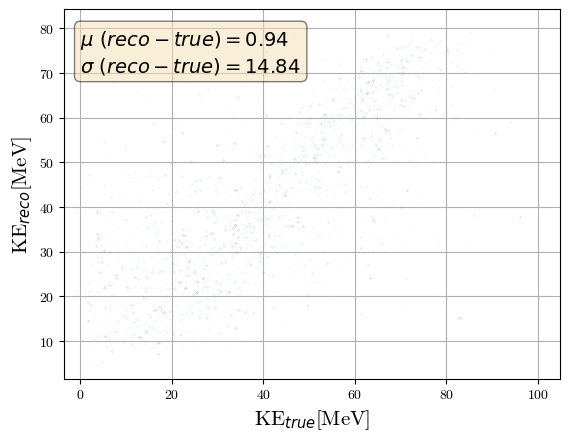

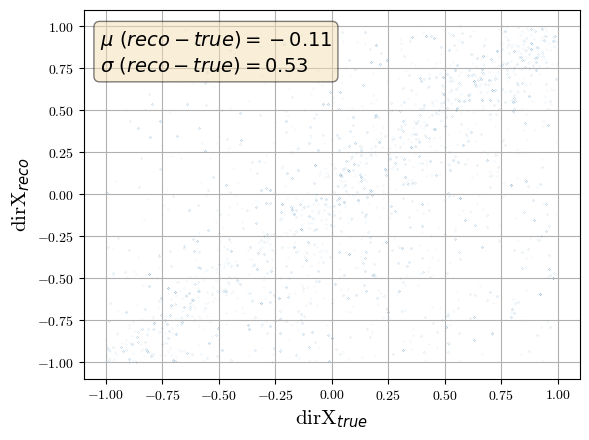

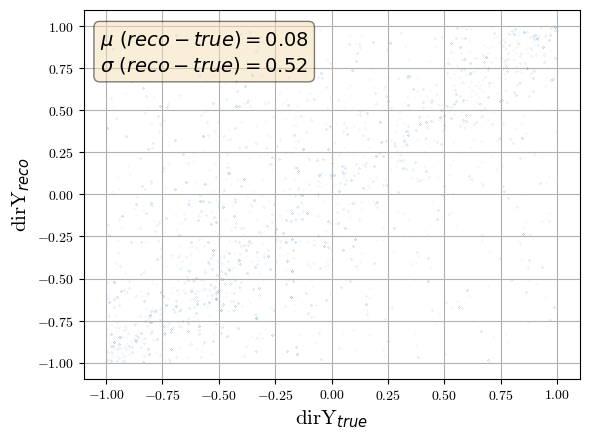

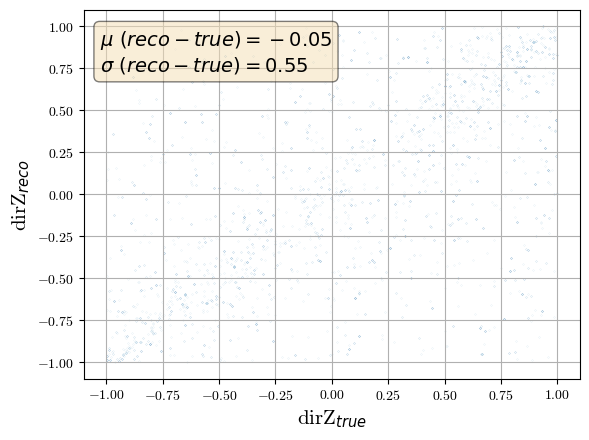

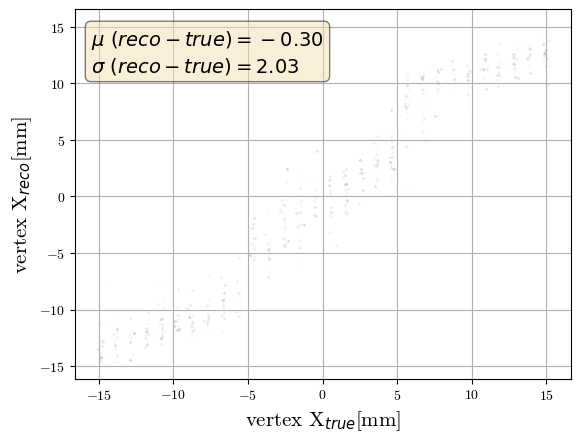

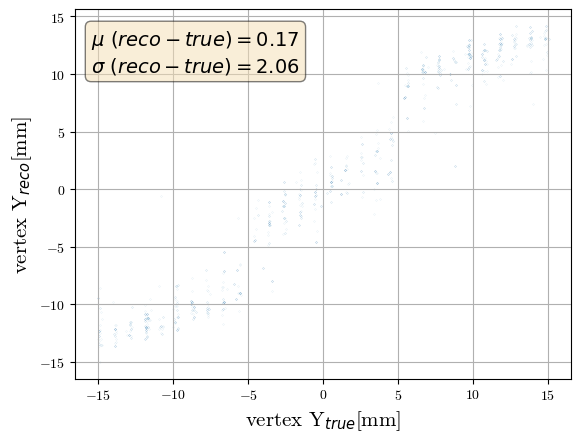

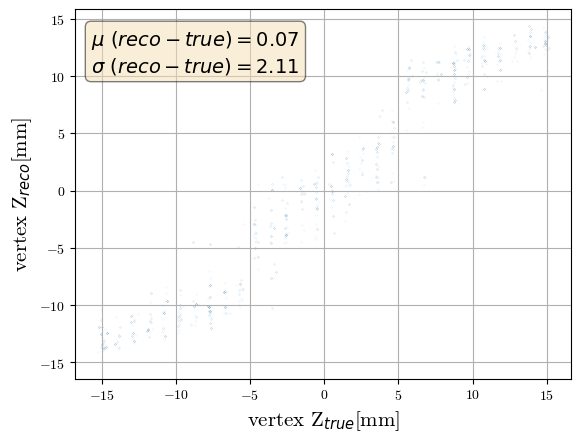

In [14]:
s = 0.0005
plot_scatter(ekin_true, ekin_pred, label=("KE","[MeV]"), s=s)

plot_scatter(dir_pred[:,0], dir_true[:,0], label=("dirX", ""), s=s*3)
plot_scatter(dir_pred[:,1], dir_true[:,1], label=("dirY", ""), s=s*3)
plot_scatter(dir_pred[:,2], dir_true[:,2], label=("dirZ", ""), s=s*3)

plot_scatter(vtx_true[:,0], vtx_pred[:,0], label=("vertex X", "[mm]"), s=s*3)
plot_scatter(vtx_true[:,1], vtx_pred[:,1], label=("vertex Y", "[mm]"), s=s*3)
plot_scatter(vtx_true[:,2], vtx_pred[:,2], label=("vertex Z", "[mm]"), s=s*3)



[[ 78  38   0   0   0]
 [ 26  75  17  12   0]
 [ 41  39  36  20   0]
 [ 28  41  50  64  33]
 [  3  19  46 139 195]]


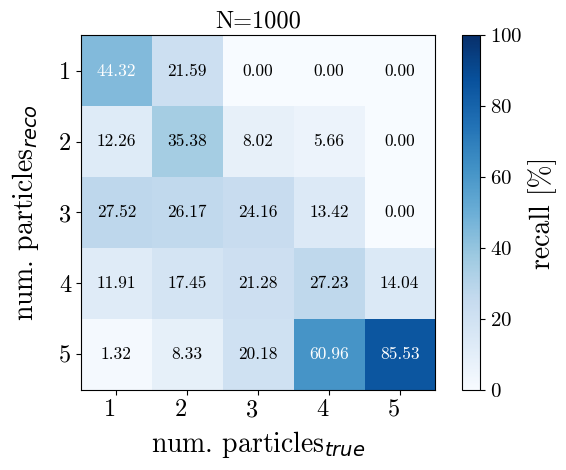

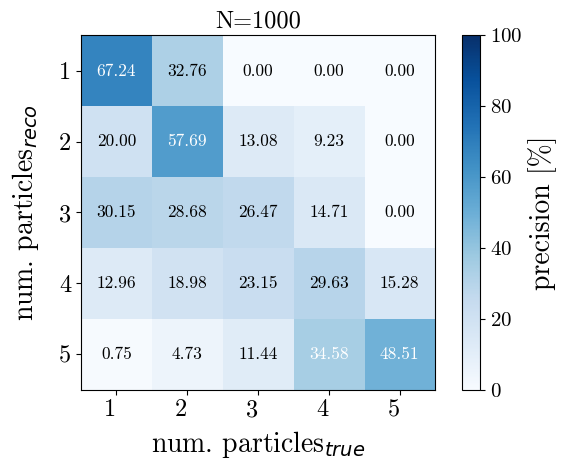

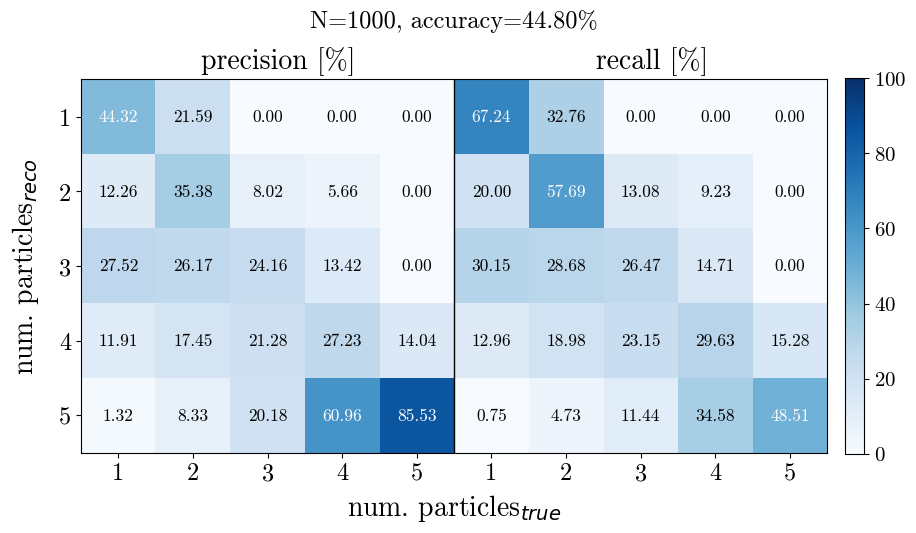

In [15]:
def plot_confusion_matrix(confusion_matrix, labels, metric="precision", N=0):
    #confusion_matrix/=confusion_matrix.sum(axis=1)
    
    fig, ax = plt.subplots()
    im = ax.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=100)
    cbar = ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(confusion_matrix.shape[1]),
           yticks=np.arange(confusion_matrix.shape[0]),
           xticklabels=labels, yticklabels=labels,
           #title='N={}'.format(N),
          )
    cbar.set_label("{} [%]".format(metric), fontsize=20)
    cbar.ax.tick_params(labelsize=15)
    
    ax.set_xlabel(r'num. particles$_{true}$', fontsize=20, labelpad=5.5)
    ax.set_ylabel(r'num. particles$_{reco}$', fontsize=20, labelpad=13)
    ax.tick_params(axis='both', labelsize=17.5)
    ax.set_title('N={}'.format(N), fontsize=17.5)
    
    plt.setp(ax.get_xticklabels(), rotation=0, ha="right",
             rotation_mode="anchor")

    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            ax.text(j, i, format(confusion_matrix[i, j], '.2f'),
                    ha="center", va="center", size=12.5,
                    color="white" if confusion_matrix[i, j] > confusion_matrix.max() / 2. else "black")
    fig.tight_layout()
    
    #plt.savefig("../images_paper/{}.pdf".format(metric))
    plt.show()
    return

def plot_confusion_matrix_combined(confusion_matrix, labels, N=0, metric="both"):
    #confusion_matrix/=confusion_matrix.sum(axis=1)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=100)
    cbar = ax.figure.colorbar(im, ax=ax, shrink=0.4875, pad=0.02)
    ax.set(xticks=np.arange(confusion_matrix.shape[1]),
           yticks=np.arange(confusion_matrix.shape[0]),
           xticklabels=labels, 
           yticklabels=labels[:confusion_matrix.shape[0]],
           #title='N={}'.format(N),
          )
    
    middle_line_position = confusion_matrix.shape[1] / 2 - 0.5
    ax.axvline(middle_line_position, color='black', linewidth=1)  # You can customize the color and linewidth

    #cbar.set_label("%", fontsize=20)
    cbar.ax.tick_params(labelsize=15)
    
    ax.set_xlabel(r'num. particles$_{true}$', fontsize=20, labelpad=5.5)
    ax.set_ylabel(r'num. particles$_{reco}$', fontsize=20, labelpad=13)
    ax.tick_params(axis='both', labelsize=17.5)
    #ax.set_title('N={}\nprecision [%]                               recall [%]'.format(N), fontsize=17.5)
    
    title = ax.set_title('')
    title_text = 'N={0}, accuracy={1:.2f}%'
    second_line_text = 'precision [%]                          recall [%]'
    title.set_text('')
    title_text_obj = ax.text(0.5, 1.14, title_text.format(N, acc*100), transform=ax.transAxes, ha='center', fontsize=17.5)
    second_line_text_obj = ax.text(0.5, 1.03, second_line_text, transform=ax.transAxes, ha='center', fontsize=20)

    plt.setp(ax.get_xticklabels(), rotation=0, ha="center",
             rotation_mode="anchor")

    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            ax.text(j, i, format(confusion_matrix[i, j], '.2f'),
                    ha="center", va="center", size=12.5,
                    color="white" if confusion_matrix[i, j] > confusion_matrix.max() / 2. else "black")
    fig.tight_layout()
    
    #plt.savefig("../images_paper/{}_cluster.pdf".format(metric))
    plt.show()
    return

from sklearn.metrics import classification_report, confusion_matrix
acc = accuracy_score(N_true, N_pred)
conf = confusion_matrix(N_pred, N_true, labels=[1,2,3,4,5])
print(conf)

conf_recall = conf/conf.sum(axis=0).reshape(-1,1)*100
conf_precis = conf/conf.sum(axis=1).reshape(-1,1)*100

#plot_confusion_matrix(conf, labels=[1,2,3,4,5])
plot_confusion_matrix(conf_recall, labels=[1,2,3,4,5], metric="recall", N=conf.sum())
plot_confusion_matrix(conf_precis, labels=[1,2,3,4,5], metric="precision", N=conf.sum())

plot_confusion_matrix_combined(np.column_stack((conf_recall, conf_precis)), 
                               labels=[1,2,3,4,5]*2, N=conf.sum())
